# Prática: Problema do Caixeiro Chinês

## Objetivo
Implementar e testar um algoritmo para a solução ótima do problema do Caixeiro Chinês.

## Estrutura do Trabalho

### 1. Implementação do Algoritmo
- Desenvolver um algoritmo para a solução ótima do problema do Caixeiro Chinês.
- O código deve ser bem comentado, destacando:
  - Implementação do algoritmo de caminho mínimo
  - Implementação do emparelhamento
  - Implementação dos testes

### 2. Testes do Algoritmo
O algoritmo deve ser testado em 5 instâncias:
- **I.** Instância apresentada em aula (para testar a corretude da implementação)
- **II.** 4 instâncias apresentadas no AVA, contendo as distâncias entre pares de cidades

### Observações
- Pode-se utilizar as linguagens: Java, C, C++ ou Python

## Entregas
- Relatório via Moodle contendo:
  - Percurso encontrado em cada instância
  - Explicação da solução para a seleção dos emparelhamentos
- Código fonte comentado via Moodle, destacando as implementações mencionadas acima

## Parte I: Teste com Instância Apresentada em Aula

Nesta seção, será implementado e testado o algoritmo para o problema do Caixeiro Chinês utilizando a biblioteca NetworkX, com uma instância simples para validar a corretude da solução.

In [87]:
import networkx as nx
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import os

# Define explicitamente o diretório de saída para salvar tudo em 'pratica02/relatorio/resultado'
output_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'relatorio', 'resultado'))

def plotar_grafo(lista_adjacencia, titulo='Grafo', pos=None, nome_fig=None, mostrar_caminho=False):
    """
    Recebe uma lista de adjacência e plota o grafo correspondente.
    Parâmetro opcional 'pos' para definir as posições dos vértices.
    Se nome_fig for fornecido, salva a figura no diretório de resultados.
    Se mostrar_caminho=True, exibe o caminho do arquivo salvo.
    """
    import networkx as nx
    import matplotlib.pyplot as plt
    G = nx.Graph()
    for u, v, peso in lista_adjacencia:
        G.add_edge(u, v, weight=peso)
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
    labels = nx.get_edge_attributes(G, 'weight')
    plt.figure(figsize=(8,5))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700, font_size=12)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title(titulo)
    if nome_fig is not None:
        os.makedirs(output_dir, exist_ok=True)
        caminho_fig = os.path.join(output_dir, nome_fig)
        plt.savefig(caminho_fig, bbox_inches='tight', dpi=150)
        if mostrar_caminho:
            print(f'Arquivo salvo em: {caminho_fig}')
    plt.show()

def plotar_circuito(G, circuito, titulo='Circuito Euleriano Colorido', pos=None, nome_fig=None, mostrar_caminho=False):
    """
    Plota o grafo e destaca o circuito euleriano com cor diferente.
    Se nome_fig for fornecido, salva a figura no diretório de resultados.
    Se mostrar_caminho=True, exibe o caminho do arquivo salvo.
    """
    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    # Todas as arestas do grafo
    edge_colors = []
    circuito_edges = set((min(u,v), max(u,v)) for u,v in circuito)
    for u, v in G.edges():
        if (min(u,v), max(u,v)) in circuito_edges:
            edge_colors.append('red')
        else:
            edge_colors.append('gray')
    
    labels = nx.get_edge_attributes(G, 'weight')
    plt.figure(figsize=(8,5))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color=edge_colors, node_size=700, font_size=12, width=2)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title(titulo)
    if nome_fig is not None:
        os.makedirs(output_dir, exist_ok=True)
        caminho_fig = os.path.join(output_dir, nome_fig)
        plt.savefig(caminho_fig, bbox_inches='tight', dpi=150)
        if mostrar_caminho:
            print(f'Arquivo salvo em: {caminho_fig}')
    plt.show()

def plotar_circuito_sem_sobreposicao(G, circuito, titulo='Circuito Euleriano Colorido', pos=None, nome_fig=None, mostrar_caminho=False):
    """
    Plota o grafo e destaca o circuito euleriano com cor diferente.
    Arestas duplicadas são desenhadas como curvas (meia-côncavas) para não sobrepor as originais.
    Se nome_fig for fornecido, salva a figura no diretório de resultados.
    Se mostrar_caminho=True, exibe o caminho do arquivo salvo.
    """
    import matplotlib.pyplot as plt
    import networkx as nx
    
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
    
    # G deve ser MultiGraph para permitir arestas duplicadas
    if not isinstance(G, nx.MultiGraph):
        G = nx.MultiGraph(G)
    
    # Conta as arestas do circuito (considerando duplicadas)
    circuito_multiedges = []
    for i, (u, v) in enumerate(circuito):
        circuito_multiedges.append((u, v, i))  # i serve para diferenciar cada passagem
    
    # Organiza as arestas do grafo por quantidade de duplicidade
    edge_count = {}
    for u, v, k in G.edges(keys=True):
        edge = tuple(sorted([u, v]))
        edge_count[edge] = edge_count.get(edge, 0) + 1
    
    plt.figure(figsize=(10,8))
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=700)
    nx.draw_networkx_labels(G, pos, font_size=12)
    
    # Desenha arestas normais (não duplicadas)
    normal_edges = []
    for u, v, k in G.edges(keys=True):
        edge = tuple(sorted([u, v]))
        if edge_count[edge] == 1:
            normal_edges.append((u, v))
    nx.draw_networkx_edges(G, pos, edgelist=normal_edges, edge_color='gray', width=2)
    
    # Desenha arestas duplicadas do circuito como curvas vermelhas, sem sobrepor
    for idx, (u, v, i) in enumerate(circuito_multiedges):
        edge = tuple(sorted([u, v]))
        if edge_count[edge] > 1:
            rad = 0.2 + 0.15 * (i % edge_count[edge])  # Curvatura diferente para cada duplicada
            nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], edge_color='red', width=2, connectionstyle=f'arc3,rad={rad}')
        else:
            nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], edge_color='red', width=2)
    
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title(titulo)
    if nome_fig is not None:
        os.makedirs(output_dir, exist_ok=True)
        caminho_fig = os.path.join(output_dir, nome_fig)
        plt.savefig(caminho_fig, bbox_inches='tight', dpi=150)
        if mostrar_caminho:
            print(f'Arquivo salvo em: {caminho_fig}')
    plt.show()

def caixeiro_chines(lista_adjacencia):
    """
    Recebe uma lista de adjacência no formato:
    [ ('A', 'B', 2), ('A', 'C', 3), ... ]
    Retorna o circuito euleriano encontrado e o grafo eulerizado.
    """
    G = nx.Graph()
    for u, v, peso in lista_adjacencia:
        G.add_edge(u, v, weight=peso)
    
    # Euleriza o grafo se necessário
    G_euler = nx.eulerize(G)
    
    # Encontra o circuito euleriano
    circuito = list(nx.eulerian_circuit(G_euler))
    return circuito, G_euler

def tabela_percurso(circuito, G_euler, nome_csv='percurso.csv', mostrar_caminho=False):
    dados = []
    for u, v in circuito:
        # Busca robusta do peso para MultiGraph e Graph
        peso = '-'
        if isinstance(G_euler, nx.MultiGraph):
            # MultiGraph: pode haver múltiplas arestas, pega o primeiro peso disponível
            edge_data = G_euler.get_edge_data(u, v)
            if edge_data:
                # edge_data é um dict de dicts: {0: {...}, 1: {...}, ...}
                for k in edge_data:
                    if 'weight' in edge_data[k]:
                        peso = edge_data[k]['weight']
                        break
        else:
            # Graph: acesso direto
            if G_euler.has_edge(u, v):
                peso = G_euler[u][v].get('weight', '-')
        dados.append({'Origem': u, 'Destino': v, 'Peso': peso})

    df = pd.DataFrame(dados)
    print(df)
    # Salvar CSV no diretório relatorio/resultado
    os.makedirs(output_dir, exist_ok=True)
    caminho_csv = os.path.join(output_dir, nome_csv)
    df.to_csv(caminho_csv, index=False, encoding='utf-8')
    if mostrar_caminho:
        print(f'Arquivo salvo em: {caminho_csv}')

# Para MultiGraph, pega o peso da primeira aresta entre u e v
def mostrar_percurso(circuito):
    print("Origem | Destino | Peso")
    for u, v in circuito:
        dados_arestas = G_euler.get_edge_data(u, v)
        if isinstance(dados_arestas, dict):
            # MultiGraph: pega o primeiro peso disponível
            if 0 in dados_arestas:
                peso = dados_arestas[0].get('weight', '-')
            else:
                # Caso não seja MultiGraph, pega direto
                peso = list(dados_arestas.values())[0].get('weight', '-')
        else:
            peso = '-'
        print(f"{u:>6} | {v:>7} | {peso:>4}")

# Função para extrair e exibir todas as propriedades relevantes do grafo eulerizado
def mostrar_info_grafo(G):
    print('--- Informações do Grafo ---')
    print(f'Nº de vértices: {G.number_of_nodes()}')
    print(f'Nº de arestas: {G.number_of_edges()}')
    print('Vértices:', list(G.nodes()))
    print('Arestas:', list(G.edges(data=True)))
    print('Graus dos vértices:')
    for n, d in G.degree():
        print(f'  {n}: grau {d}')
    print('Pesos das arestas:')
    for u, v, data in G.edges(data=True):
        print(f'  ({u}, {v}): {data.get("weight", None)}')
    print('Matriz de adjacência:')
    print(nx.to_numpy_array(G))
    print('É conexo?', nx.is_connected(G))
    print('É euleriano?', nx.is_eulerian(G))
    print('Componentes conexas:', list(nx.connected_components(G)))
    print('--- Fim das informações ---')


## Parte II: Teste com Instância Apresentada em Aula

A segunda parte do trabalho consiste no teste do algoritmo implementadoem5 instâncias:

### I - Instância apresentada em aula a fim de testar a corretude da implementação:

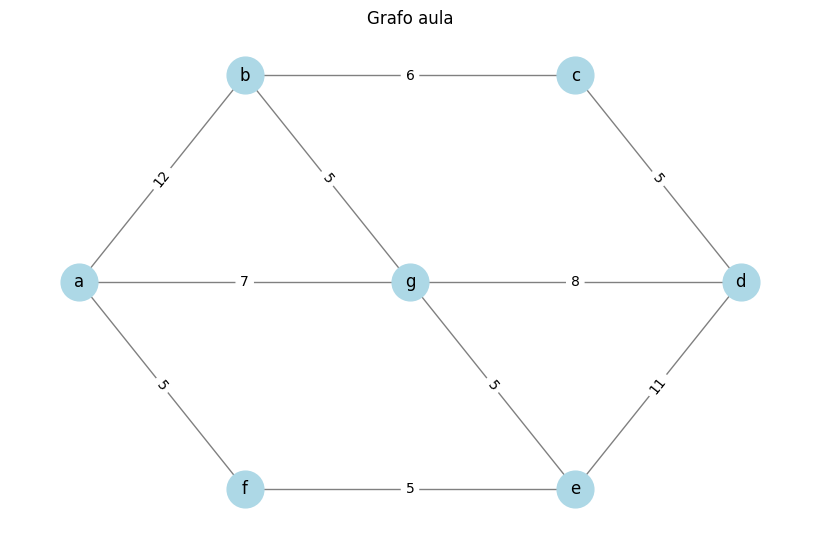

Origem | Destino | Peso
     a |       f |    5
     f |       e |    5
     e |       d |   11
     d |       e |   11
     e |       g |    5
     g |       d |    8
     d |       c |    5
     c |       b |    6
     b |       g |    5
     g |       a |    7
     a |       b |   12
     b |       a |   12


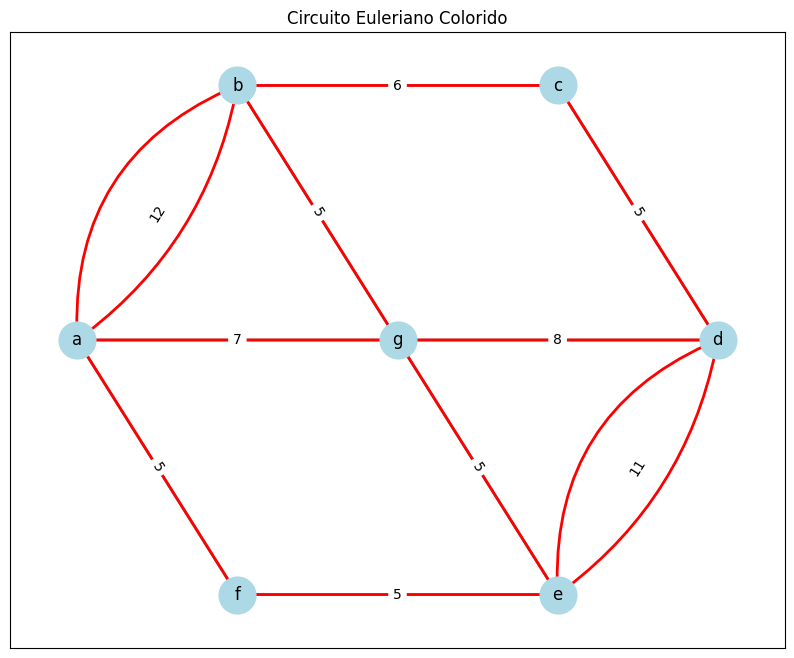

--- Informações do Grafo ---
Nº de vértices: 7
Nº de arestas: 12
Vértices: ['a', 'b', 'g', 'f', 'c', 'd', 'e']
Arestas: [('a', 'b', {'weight': 12}), ('a', 'b', {}), ('a', 'g', {'weight': 7}), ('a', 'f', {'weight': 5}), ('b', 'c', {'weight': 6}), ('b', 'g', {'weight': 5}), ('g', 'e', {'weight': 5}), ('g', 'd', {'weight': 8}), ('f', 'e', {'weight': 5}), ('c', 'd', {'weight': 5}), ('d', 'e', {'weight': 11}), ('d', 'e', {})]
Graus dos vértices:
  a: grau 4
  b: grau 4
  g: grau 4
  f: grau 2
  c: grau 2
  d: grau 4
  e: grau 4
Pesos das arestas:
  (a, b): 12
  (a, b): None
  (a, g): 7
  (a, f): 5
  (b, c): 6
  (b, g): 5
  (g, e): 5
  (g, d): 8
  (f, e): 5
  (c, d): 5
  (d, e): 11
  (d, e): None
Matriz de adjacência:
[[ 0. 13.  7.  5.  0.  0.  0.]
 [13.  0.  5.  0.  6.  0.  0.]
 [ 7.  5.  0.  0.  0.  8.  5.]
 [ 5.  0.  0.  0.  0.  0.  5.]
 [ 0.  6.  0.  0.  0.  5.  0.]
 [ 0.  0.  8.  0.  5.  0. 12.]
 [ 0.  0.  5.  5.  0. 12.  0.]]
É conexo? True
É euleriano? True
Componentes conexas: [{'f',

In [88]:
# Exemplo de uso
lista = [
    ('a', 'b', 12),
    ('a', 'g', 7),
    ('a', 'f', 5),
    ('b', 'c', 6),
    ('b', 'g', 5),
    ('c', 'd', 5),
    ('d', 'e', 11),
    ('e', 'f', 5),
    ('e', 'g', 5),
    ('g', 'd', 8)
    ]

pos = { 'a': (0,0), 
        'b': (2,2), 
        'c': (6,2), 
        'd': (8,0),
        'e': (6,-2),
        'f': (2,-2),
        'g': (4,0),
        }

plotar_grafo(lista, titulo='Grafo aula', pos=pos, nome_fig='grafo_aula.png')
circuito, G_euler = caixeiro_chines(lista)
mostrar_percurso(circuito)
plotar_circuito_sem_sobreposicao(G_euler, circuito, titulo='Circuito Euleriano Colorido', pos=pos, nome_fig='circuito_euleriano_aula.png')
mostrar_info_grafo(G_euler)
tabela_percurso(circuito, G_euler, nome_csv='percurso_aula.csv')


### II.04 instâncias apresentadas no AVA contendo as distâncias entre pares de cidades;

Instância: gr15.tsp
Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\grafo_gr15.tsp.png
Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\grafo_gr15.tsp.png


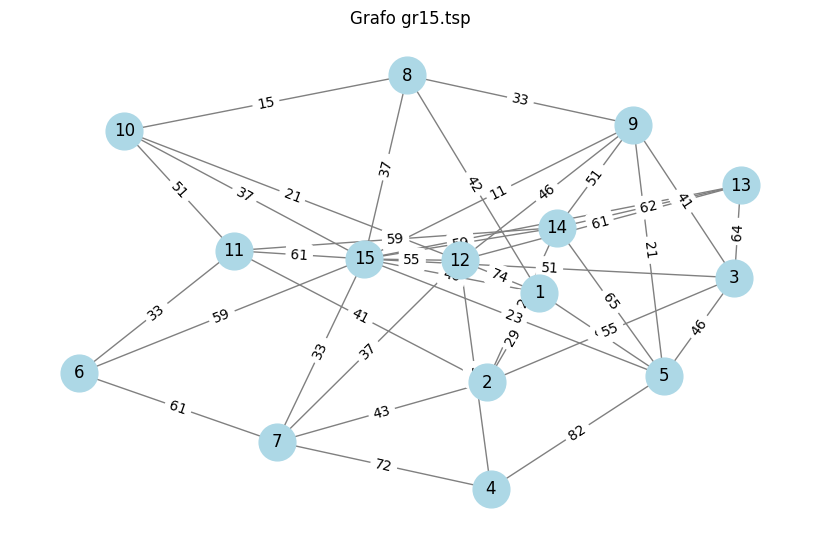

Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\circuito_euleriano_gr15.tsp.png


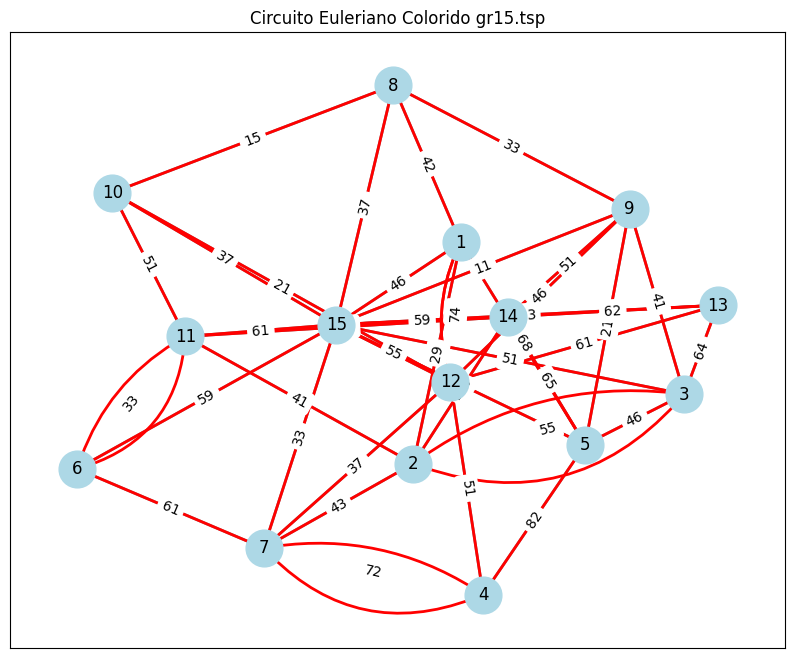

Origem | Destino | Peso
     1 |      12 |   74
    12 |      15 |   55
    15 |      14 |   59
    14 |      13 |   62
    13 |       3 |   64
     3 |       9 |   41
     9 |      14 |   51
    14 |      11 |   59
    11 |       6 |   33
     6 |      11 |   33
    11 |      10 |   51
    10 |      15 |   37
    15 |       7 |   33
     7 |       4 |   72
     4 |       7 |   72
     7 |       6 |   61
     6 |      15 |   59
    15 |      13 |   23
    13 |      12 |   61
    12 |      10 |   21
    10 |       8 |   15
     8 |      15 |   37
    15 |      11 |   61
    11 |       2 |   41
     2 |      14 |   52
    14 |       5 |   65
     5 |      15 |   23
    15 |       9 |   11
     9 |      12 |   46
    12 |       4 |   51
     4 |       5 |   82
     5 |       9 |   21
     9 |       8 |   33
     8 |       1 |   42
     1 |      15 |   46
    15 |       3 |   51
     3 |       5 |   46
     5 |       1 |   68
     1 |      12 |   74
    12 |       7 |   37
     7 |       2

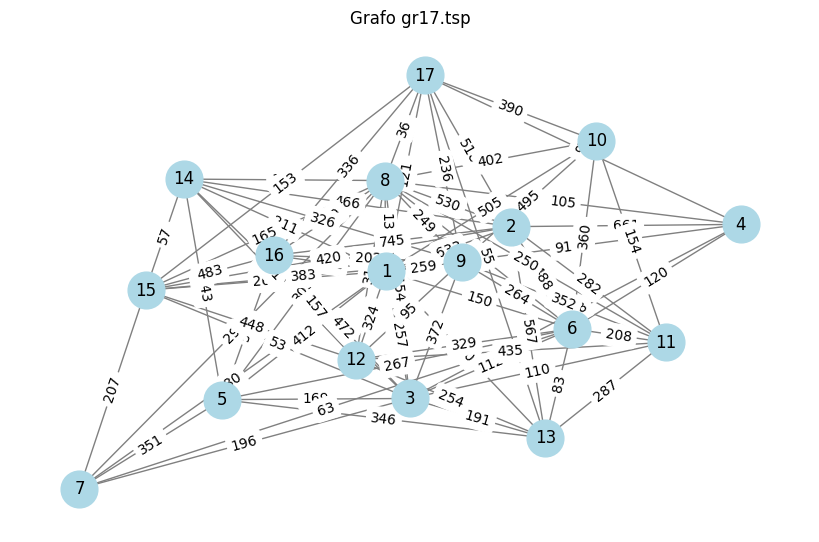

Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\circuito_euleriano_gr17.tsp.png


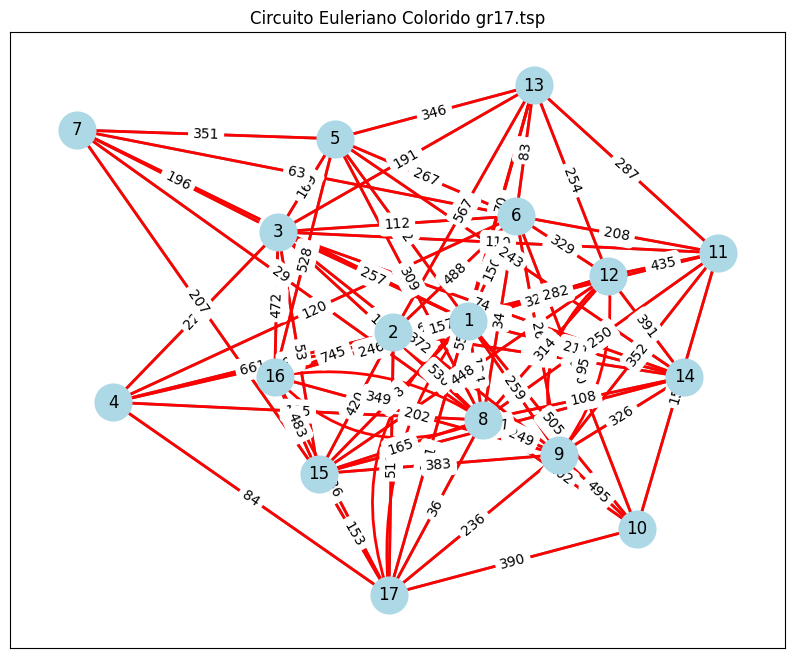

Origem | Destino | Peso
     1 |      17 |  121
    17 |      16 |  336
    16 |      15 |  483
    15 |      14 |   57
    14 |      12 |  391
    12 |      15 |  448
    15 |      17 |  153
    17 |      13 |   55
    13 |      11 |  287
    11 |      12 |  435
    12 |      16 |  157
    16 |       8 |  349
     8 |      16 |  349
    16 |       9 |  202
     9 |      15 |  383
    15 |       8 |  165
     8 |      14 |  108
    14 |       9 |  326
     9 |      12 |   95
    12 |       9 |   95
     9 |      17 |  236
    17 |      10 |  390
    10 |      11 |  154
    11 |       8 |  250
     8 |      12 |  314
    12 |      13 |  254
    13 |       6 |   83
     6 |      11 |  208
    11 |       9 |  352
     9 |      10 |  495
    10 |       8 |  402
     8 |      17 |   36
    17 |       2 |  518
     2 |      15 |  420
    15 |       3 |   53
     3 |      16 |  472
    16 |       5 |  528
     5 |      14 |  243
    14 |       2 |  466
     2 |      16 |  745
    16 |       1

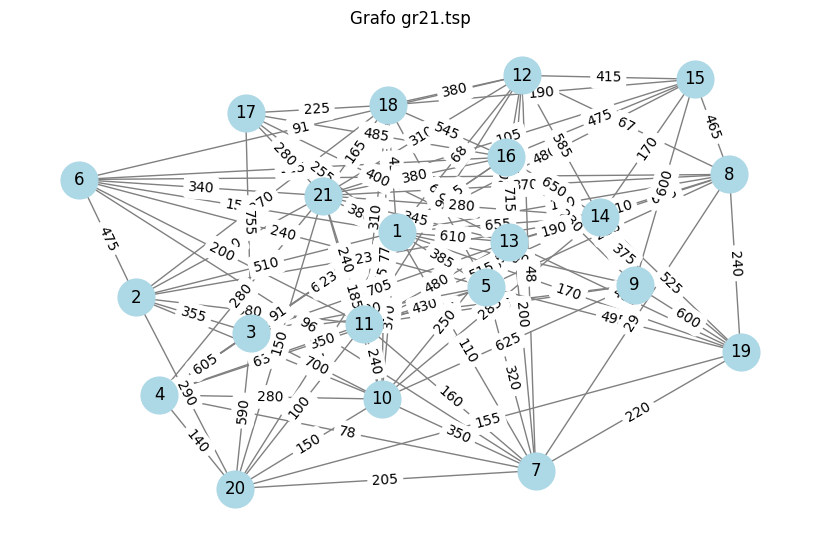

Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\circuito_euleriano_gr21.tsp.png


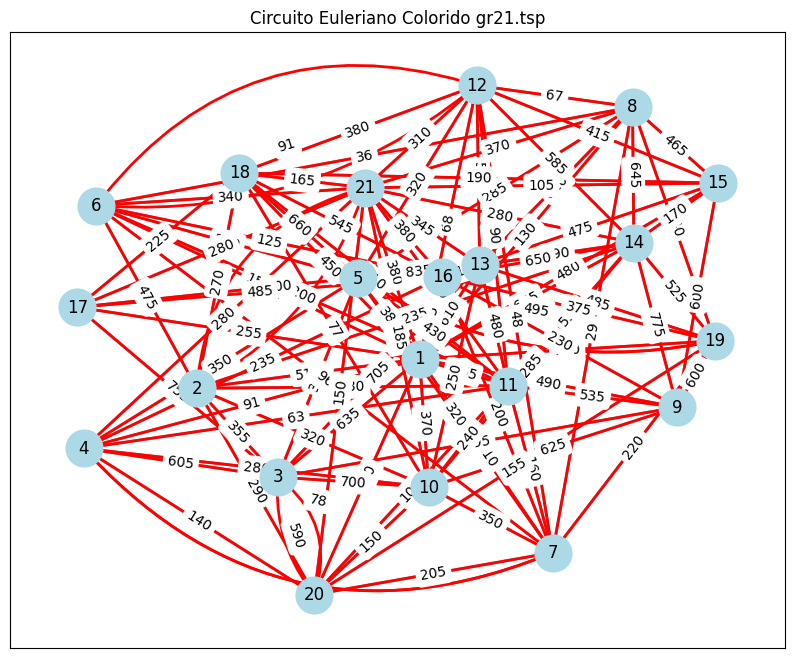

Origem | Destino | Peso
     1 |      21 |  380
    21 |      18 |  165
    18 |      17 |  225
    17 |      21 |  280
    21 |      20 |  150
    20 |      19 |  155
    19 |      16 |  375
    16 |      21 |  380
    21 |      14 |  280
    14 |      19 |  525
    19 |      13 |  485
    13 |      21 |  345
    21 |      11 |  240
    11 |      20 |  100
    20 |      10 |  150
    10 |      21 |  185
    21 |      15 |  105
    15 |      18 |  190
    18 |      16 |  545
    16 |      15 |  475
    15 |      14 |  170
    14 |      16 |  650
    16 |      17 |  485
    17 |      13 |  400
    13 |      16 |  715
    16 |       9 |  230
     9 |      19 |  600
    19 |       8 |  240
     8 |      21 |  370
    21 |      12 |  310
    12 |      14 |  585
    14 |      13 |  190
    13 |      12 |  545
    12 |      18 |  380
    18 |      11 |  310
    11 |      14 |  515
    14 |      10 |  285
    10 |      13 |  250
    13 |      11 |  480
    11 |      10 |  240
    10 |      18

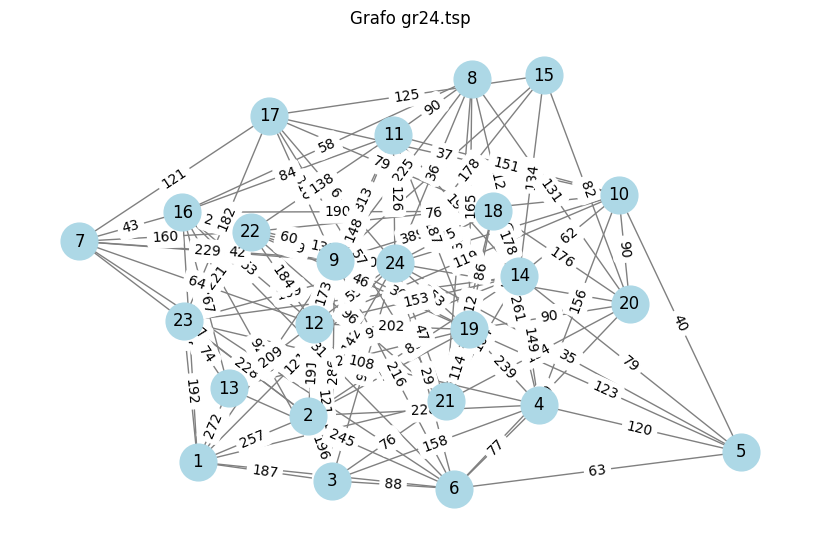

Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\circuito_euleriano_gr24.tsp.png


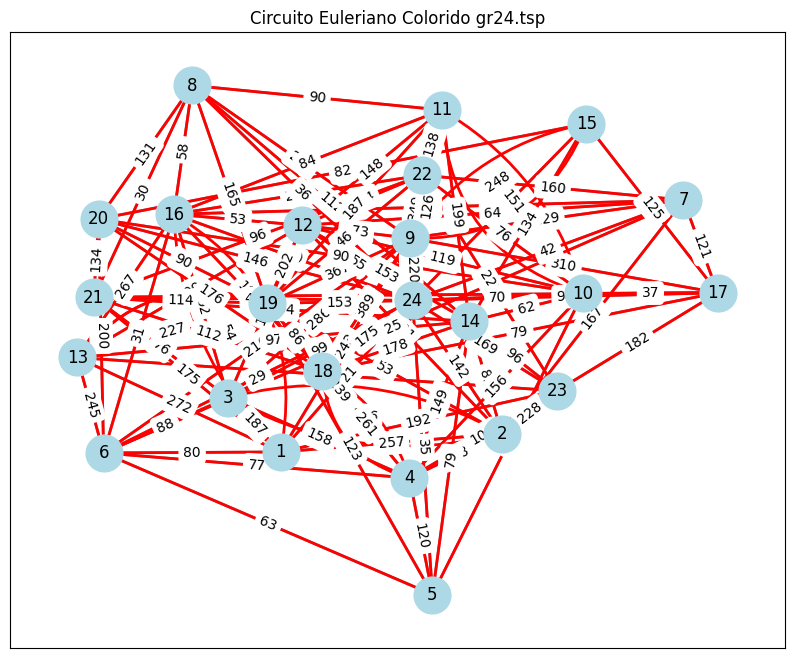

Origem | Destino | Peso
     1 |      24 |  121
    24 |      20 |  146
    20 |      15 |   82
    15 |      17 |  125
    17 |      18 |   79
    18 |      20 |  176
    20 |       8 |  131
     8 |      11 |   90
    11 |      22 |  138
    22 |      10 |   76
    10 |      20 |   90
    20 |      19 |   90
    19 |      22 |   46
    22 |       7 |  160
     7 |      17 |  121
    17 |      10 |   37
    10 |      11 |  151
    11 |      10 |  151
    10 |       5 |   40
     5 |      19 |  123
    19 |      18 |   86
    18 |       4 |  261
     4 |      18 |  261
    18 |      14 |  178
    14 |      15 |  134
    15 |      24 |  178
    24 |      22 |  135
    22 |      12 |  184
    12 |      19 |  202
    19 |      11 |  187
    11 |      14 |  199
    14 |      10 |   62
    10 |       4 |  156
     4 |      19 |  239
    19 |       8 |  165
     8 |      14 |  112
    14 |       5 |   79
     5 |       4 |  120
     4 |      14 |  149
    14 |      12 |  153
    12 |      11

In [91]:
import re

def ler_tsp_lower_diag_row(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    # Encontrar a linha EDGE_WEIGHT_SECTION
    start = None
    for i, line in enumerate(lines):
        if 'EDGE_WEIGHT_SECTION' in line:
            start = i + 1
            break
    if start is None:
        raise ValueError('EDGE_WEIGHT_SECTION não encontrada')
    # Extrair dimensão
    dim = None
    for line in lines:
        m = re.match(r'DIMENSION\s*:\s*(\d+)', line)
        if m:
            dim = int(m.group(1))
            break
    if dim is None:
        raise ValueError('DIMENSION não encontrada')
    # Ler matriz triangular inferior
    matriz = [[0]*dim for _ in range(dim)]
    idx = 0
    for i in range(dim):
        vals = []
        while len(vals) < i+1:
            vals += [int(x) for x in lines[start+idx].strip().split()]
            idx += 1
        for j in range(i+1):
            matriz[i][j] = vals[j]
            matriz[j][i] = vals[j]
    return matriz

def matriz_para_lista_adjacencia(matriz):
    dim = len(matriz)
    lista = []
    for i in range(dim):
        for j in range(i+1, dim):
            if matriz[i][j] > 0:
                lista.append((str(i+1), str(j+1), matriz[i][j]))
    return lista

# Caminhos dos arquivos (corrigido)
arquivos = ['gr15.tsp', 'gr17.tsp', 'gr21.tsp', 'gr24.tsp']
for arquivo in arquivos:
    matriz = ler_tsp_lower_diag_row(f'../{arquivo}')
    lista = matriz_para_lista_adjacencia(matriz)
    print(f'Instância: {arquivo}')
    circuito, G_euler = caixeiro_chines(lista)
    plotar_grafo(lista, titulo=f'Grafo {arquivo}', nome_fig=f'grafo_{arquivo}.png', mostrar_caminho=True)
    plotar_circuito_sem_sobreposicao(G_euler, circuito, titulo=f'Circuito Euleriano Colorido {arquivo}', nome_fig=f'circuito_euleriano_{arquivo}.png', mostrar_caminho=True)
    mostrar_percurso(circuito)
    tabela_percurso(circuito, G_euler, nome_csv=f'percurso_{arquivo}.csv')